<a href="https://colab.research.google.com/github/m4tt-nm/martino_DSPN_S26/blob/master/ExerciseSubmissions/11_the-beauty-of-knn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 11: The beauty of kNN

In this exercise, you'll gain practice working with kNN. We'll use the [diamonds](https://ggplot2.tidyverse.org/reference/diamonds.html) dataset, which comes as part of `ggplot2`. This dataset provides information on the quality and price of 50,000 diamonds.


-----
## 1. Data, Plotting, and Train/Test Sets (2 points)
* Load the the `class` and `tidyverse` packages.
* Assign the `diamonds` data set to a simpler name. Then, create a new variable `price_bin` that splits the `price` variable into a binary variable, where 1 indicates that the diamond costs greater than the mean price, and 0 indicates that the diamond costs less than the mean price. Set `price_bin` to be a factor. (*Hint: use the if_else() function*)
* Select just the `carat`, `depth`, `table`, `x`, `y`, and your new `price_bin` variables
* Print the first few lines of the data set
* Print the dimensions of the data set


In [1]:
install.packages("class")
install.packages("tidyverse")
library(class)
library(tidyverse)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [9]:
# INSERT CODE HERE
diamond.df <- diamonds
diamond.df$price_bin <- if_else(diamond.df$price > mean(diamond.df$price), 1, 0)
diamond.df <- select(diamond.df, carat, depth, table, x, y, price_bin)

head(diamond.df)
dim(diamond.df)

carat,depth,table,x,y,price_bin
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.23,61.5,55,3.95,3.98,0
0.21,59.8,61,3.89,3.84,0
0.23,56.9,65,4.05,4.07,0
0.29,62.4,58,4.20,4.23,0
0.31,63.3,58,4.34,4.35,0
0.24,62.8,57,3.94,3.96,0


[1] 53940     6

### Plot
Create a scatterplot of the link between `carat` and `depth`, and use the `color` aesthetics mapping to differentiate between diamonds that cost above versus below the mean price.

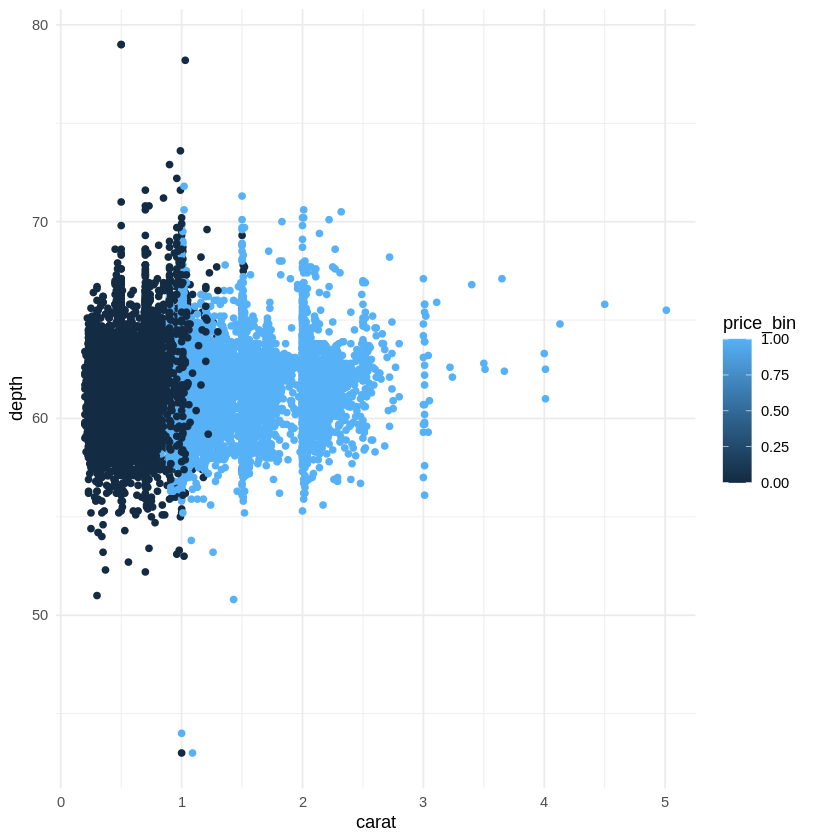

In [10]:
# INSERT CODE HERE
ggplot(diamond.df, aes(x = carat, y = depth, color = price_bin)) +
geom_point() +
theme_minimal()

Based on the above scatterplot, how do you think kNN will perform using only these two variables to predict price? Which variable, carat or depth, gives us the most information about which price class the diamond will belong to?
> * *Carat gives us more information about which price class a diamond will belong to. I believe kNN will perform well because of the clear separation at 1 carat between diamonds below and above the mean price.*
>


### Test vs Train

Before we run KNN on these data, we need to set aside a portion of the observations as our test set. Below, randomly divide the data such that 30% are allotted to the `test` set and the rest are allotted to the `train` set. Print the first few lines of each set, and print the dimensions of each set to double check your division of the data.

In [15]:
set.seed(2023)

# INSERT CODE HERE
samp <- sample(nrow(diamond.df), size = nrow(diamond.df)*.7)
train <- diamond.df[samp, ]
test <- diamond.df[-samp, ]

head(train)
head(test)
dim(train)
dim(test)



carat,depth,table,x,y,price_bin
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1.22,62.3,56.0,6.81,6.84,1
1.57,62.3,56.0,7.48,7.41,1
1.11,62.4,57.7,6.57,6.64,1
0.42,60.6,57.0,4.82,4.85,0
0.32,62.6,55.0,4.39,4.36,0
0.90,62.7,58.0,6.06,6.15,1


carat,depth,table,x,y,price_bin
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.23,61.5,55,3.95,3.98,0
0.26,61.9,55,4.07,4.11,0
0.22,65.1,61,3.87,3.78,0
0.23,62.8,56,3.93,3.90,0
0.31,62.2,54,4.35,4.37,0
0.20,60.2,62,3.79,3.75,0


[1] 37758     6

[1] 16182     6

-----
## 2. KNN (3 points)
Now, use the `knn()` function from the `class` library to predict `price_bin` from the `carat` and `depth`. Set `k = 3`.

*Hint: Review the format required for the arguments of knn()*

In [16]:
set.seed(2023)
# INSERT CODE HERE
train.preds <- cbind(train$carat, train$depth)
train.spec <- train$price_bin
test.preds <- cbind(test$carat, test$depth)

test.spec.knn <- knn(train.preds, test.preds, train.spec, k = 3)
test.spec.knn[1:10]

[1] 0 0 0 0 0 0 0 0 0 0
Levels: 0 1

Now, output a confusion matrix and calculate the test error to evaluate model performance.

In [18]:
# INSERT CODE HERE
confusion.df <- data.frame(predicted = test.spec.knn, actual = test$price_bin)
table(confusion.df)
print(paste("Accuracy:",mean(confusion.df$predicted == confusion.df$actual)))

         actual
predicted    0    1
        0 9756  302
        1  542 5582

[1] "Accuracy: 0.947843282659745"


How did your model perform?
> *The model performs well, though it is better at correctly predicting when a diamond will be below mean price than when it will be above mean price.*


Let's try to improve our model by adding all of the other variables in our data set as predictors. Rerun your `knn()` below, keeping `k = 3`. Again, output a confusion matrix and error rate for your updated model fit.

In [23]:
set.seed(2023)
# INSERT CODE HERE
train.preds <- select(train, -price_bin)
train.spec <- train$price_bin
test.preds <- select(test, -price_bin)

test.spec.knn <- knn(train.preds, test.preds, train.spec, k = 3)
#test.spec.knn[1:10]

confusion.df <- data.frame(predicted = test.spec.knn, actual = test$price_bin)
table(confusion.df)
print(paste("Accuracy:",mean(confusion.df$predicted == confusion.df$actual)))

[1] 0 0 0 0 0 0 0 0 0 0
Levels: 0 1

         actual
predicted    0    1
        0 9782  367
        1  516 5517

[1] "Accuracy: 0.945433197379805"


Did your model predictions improve?
> *No, the model predictions actually got slightly worse overall if anything even though false alarms went down.*


-----
## 3. For loop (3 points)

So adding additional predictors didn't shift our error much. Let's see if adjusting `k` has a larger impact on model accuracy.

Using your initial model above with just `carat` and `depth`, run a `for loop` that runs the same model 30 times, for `k = 1:30`.

Output a data frame that has `k` and the overall `error` as columns.

The structure of the output data frame and `for loop` are provided for you below. Note that your loop will take a minute or two to run because there are so many observations in the dataset. It may be helpful while you are writing and testing your loop to run it on a subset of the data with only a handful of rows.

In [24]:
# this is provided
# setting up empty table to store for loop output
output  <- data.frame(k = seq(1:30),
                     error = rep(NA, 30))
head(output)

,k,error
,<int>,<lgl>
1,1,NA
2,2,NA
3,3,NA
4,4,NA
5,5,NA
6,6,NA


In [ ]:
for (k in seq(1:30)) {
    knn_fits  <- # your knn function here

    #overall error
    conf_df  <- # data frame of test predictions versus actual test
    output$error[k]  <- #calculate error from conf_df and add to your output dataframe

}
head(output)

Create a line plot of your `output` object using `ggplot`. Add a (non-linear) `geom_smooth` layer.

In [ ]:
# INSERT CODE HERE

Interpret your plot. What would you select as the best value of `k`? How much does this improve your test error?
> * *Write your response here*
>
> *


-----
## 4. Standardizing predictors (2 points)

Because knn is based on distances between points, it is very sensitive to the scale of your variables. Looking at our predictor variables, we can see that `carat` and `depth` are orders of magnitude different in terms of scales. Maybe we can improve our fit even more by addressing this!

Below, use the `scale()` function to standardize your predictors. (Note that you don't need to standardize `price_bin`.)

Then, run your model a final time with your standardized predictors (just `carat` and `depth` still). Set `k` to the optimal value you determined in your plot above. Output the confusion matrix and error rate again.

In [ ]:
set.seed(2023)
#INSERT CODE HERE


What impact did rescaling the data have on your error rate?
> * *Write response here*
>
> *


**DUE:** 11:59pm March 17, 2026

**IMPORTANT** Did you collaborate with anyone on this assignment? If so, list their names here.
> *No*
>
>


**GenAI Utilization** Did you utilize any generative AI tools on this assignment? If so, please list the item and the paste respective prompt you used.
No